# Project 1: Heart Segmentation Model — Colab Evaluation Notebook
## Radiomics & Phenotyping | COCA Dataset

**How to use:**
1. Run `prepare_drive_upload.ps1` locally — it copies all 50 scans **and** `Preprocessing.ipynb` to `CT_Datasets_Drive\`.
2. Upload `CT_Datasets_Drive\` to your Google Drive.
3. Open this notebook in **Google Colab** (GPU runtime).
4. Set `DRIVE_ROOT` in cell 1 to the Drive path (e.g. `/content/drive/MyDrive/CT_Datasets_Drive`).
5. Run all cells — setup is loaded directly from `Preprocessing.ipynb` via `nbformat`, no code duplication.

**Design:**
- Cell 2 uses `nbformat` to execute the setup cells of `Preprocessing.ipynb` (imports, `Config`, HU-windowing, MONAI transforms, `CardiacCTDataset`) into this kernel. `Config` paths are patched automatically to point to Drive.
- `HeartPatch3DDataset` wraps `CardiacCTDataset` and reuses `train_transforms` + `intensity_transforms` verbatim.
- **5-fold K-Fold cross-validation** is used instead of a single split: more reliable Dice estimate on 50 scans.
- A fixed held-out test set (`data_split.json`) is evaluated once using the best-fold checkpoint.


In [3]:
# ── Step 1: Mount Google Drive ────────────────────────────────────────────────
DRIVE_ROOT = "/content/drive/MyDrive/CT_Datasets_Drive"

import os
if not os.path.isdir("/content/drive"):
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        print("Drive mounted.")
    except ImportError:
        print("Not running in Colab — DRIVE_ROOT presumed already accessible.")
else:
    print("Drive already mounted.")

if not os.path.isdir(DRIVE_ROOT):
    raise FileNotFoundError(
        f"\nDRIVE_ROOT not found: {DRIVE_ROOT}\n"
        "Upload CT_Datasets_Drive/ to your Drive and update DRIVE_ROOT above."
    )
print(f"DRIVE_ROOT OK → {DRIVE_ROOT}")

# ── Step 2: Install required packages (Colab only) ────────────────────────────
try:
    import monai, SimpleITK
    print("MONAI and SimpleITK already installed.")
except ImportError:
    print("Installing packages…")
    os.system("pip install -q monai[all] SimpleITK scikit-learn tqdm")
    print("Packages installed.")


Mounted at /content/drive
Drive mounted.
DRIVE_ROOT OK → /content/drive/MyDrive/CT_Datasets_Drive
Installing packages…
Packages installed.


In [4]:
"""
Load setup cells from Preprocessing.ipynb into this kernel's namespace.

Drive layout (produced by prepare_drive_upload.ps1):
    CT_Datasets_Drive/
      scans/<scan_id>/{scan_id}_img.nii.gz + {scan_id}_seg.nii.gz (HEART seg)
      data_split.json
      processing_results.json
      selected_scans.json
      Preprocessing.ipynb

Cells loaded (0-based index in Preprocessing.ipynb):
  2  - imports
  3  - Config class  (OUTPUT_DIR.mkdir stripped — runs at class-def time)
  9  - apply_hu_windowing / apply_multi_windowing
  14 - train_transforms, intensity_transforms
  19 - CardiacCTDataset class definition
"""
import nbformat, time, json
from pathlib import Path
from IPython import get_ipython as _gip

PREP_NB = str(Path(DRIVE_ROOT) / "Preprocessing.ipynb")

def _load_preprocessing(nb_path, drive_root):
    ip = _gip()
    if "config" in ip.user_ns:
        print("Preprocessing already loaded in this session - skipping.")
        return

    print(f"Loading setup from {nb_path} ...\n")
    with open(nb_path) as f:
        nb = nbformat.read(f, as_version=4)

    def _src(idx, stop=None):
        src = nb.cells[idx].source
        if stop:
            cut = src.find(stop)
            if cut > 0:
                src = src[:cut]
        return src

    def _run(label, src):
        t0     = time.time()
        result = ip.run_cell(src)
        status = "OK" if not result.error_in_exec else f"FAIL  {result.error_in_exec}"
        print(f"  [{status}]  {label}  ({time.time()-t0:.1f}s)")
        if result.error_in_exec:
            raise RuntimeError(f"{label} failed: {result.error_in_exec}")
        return result

    _root = Path(drive_root)

    # 1. Imports
    _run("Imports          ", _src(2))

    # 2. Config — strip OUTPUT_DIR.mkdir() from class body (runs at def time)
    _config_src = _src(3).replace("\n    OUTPUT_DIR.mkdir(exist_ok=True)", "")
    _run("Config           ", _config_src)

    # Patch paths to Drive immediately after Config is created
    cfg = ip.user_ns.get("config")
    if cfg is None:
        raise RuntimeError("Config cell did not produce a `config` object.")
    cfg.BASE_DIR   = _root
    cfg.DATA_DIR   = _root / "scans"          # heart img + seg
    cfg.OUTPUT_DIR = _root / "outputs"        # models, plots, CSV
    cfg.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    ip.user_ns["config"] = cfg
    print(f"     Config paths patched -> {_root}")

    # 3. HU windowing helpers
    _run("HU windowing fns ", _src(9, "\n# Test HU windowing"))

    # 4. Augmentation transforms
    _run("Aug. transforms  ", _src(14))

    # 5. CardiacCTDataset class
    _run("CardiacCTDataset ", _src(19, "\n# Create datasets"))

    # 6. Scan list from selected_scans.json (at Drive root)
    with open(_root / "selected_scans.json") as f:
        ip.user_ns["all_valid_scans"] = json.load(f)
    print(f"  [OK]  Scan list  ({len(ip.user_ns['all_valid_scans'])} scans)")

    # 7. TotalSegmentator timing baseline (at Drive root)
    with open(_root / "processing_results.json") as f:
        _ts = json.load(f)
    ip.user_ns["ts_times"] = _ts["processing_times_seconds"]
    ip.user_ns["ts_stats"] = _ts["timing_statistics"]

    print("\nReady. Available from Preprocessing:")
    print("  config  (DATA_DIR=scans/, OUTPUT_DIR=outputs/)")
    print("  apply_hu_windowing, apply_multi_windowing")
    print("  train_transforms, intensity_transforms")
    print("  CardiacCTDataset")
    print("  all_valid_scans, ts_times, ts_stats")

_load_preprocessing(PREP_NB, DRIVE_ROOT)


Loading setup from /content/drive/MyDrive/CT_Datasets_Drive/Preprocessing.ipynb ...

All libraries imported successfully!
  [OK]  Imports            (35.4s)
Data directory: C:\CT_Datasets/totalsegmentator_output
Using TotalSegmentator heart segmentations (not calcium)
Multi-window input: [{'center': 40, 'width': 400}, {'center': 100, 'width': 600}]
  [OK]  Config             (0.0s)
     Config paths patched -> /content/drive/MyDrive/CT_Datasets_Drive
  [OK]  HU windowing fns   (0.0s)
Whole-heart augmentation pipeline defined:
- Spatial: affine + 3D elastic deformation
- Intensity: Gaussian noise, smoothing, intensity scaling/shifting
  [OK]  Aug. transforms    (0.0s)
  [OK]  CardiacCTDataset   (0.0s)
  [OK]  Scan list  (50 scans)

Ready. Available from Preprocessing:
  config  (DATA_DIR=scans/, OUTPUT_DIR=outputs/)
  apply_hu_windowing, apply_multi_windowing
  train_transforms, intensity_transforms
  CardiacCTDataset
  all_valid_scans, ts_times, ts_stats


In [5]:
# ── Segmentation-specific imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import time, json, shutil
from pathlib import Path

import SimpleITK as sitk
from monai.losses import DiceLoss
from monai.inferers import SlidingWindowInferer
from monai.networks.nets import UNet as MonaiUNet
from sklearn.model_selection import KFold

print("Imports OK.")


Imports OK.


## 1. 3-D Patch Dataset

`HeartPatch3DDataset` wraps `CardiacCTDataset` (same HU windowing, same caching)
and adds **positive-biased 3-D patch sampling** so the model sees a heart voxel
in most patches. Augmentation reuses `train_transforms` and `intensity_transforms`
defined above.


In [6]:
class HeartPatch3DDataset(Dataset):
    """
    3-D patch dataset that sits on top of Preprocessing.ipynb's CardiacCTDataset.

    Reused from Preprocessing (zero code duplication):
      - CardiacCTDataset   → volume loading, multi-window HU normalisation, caching
      - train_transforms   → RandAffine + Rand3DElastic (Section 5 of Preprocessing)
      - intensity_transforms → GaussianNoise/Smooth, ScaleIntensity, ShiftIntensity

    Added here (segmentation-specific):
      - Positive-biased 3-D patch sampling: `pos_prob` fraction of crops are
        centred on randomly chosen heart voxels, ensuring the model sees the
        target structure in most patches without discarding any full volume.
    """

    def __init__(self, scan_ids, augment=False,
                 samples_per_volume: int = 8,
                 pos_prob: float = 0.67):
        # CardiacCTDataset from Preprocessing — cache=True keeps all 50 vols in RAM
        self.base     = CardiacCTDataset(scan_ids, config.DATA_DIR, config,
                                         augment=False, cache=True)
        self.augment  = augment
        self.spv      = samples_per_volume
        self.pos_prob = pos_prob
        self.pd, self.ph, self.pw = PATCH_SIZE
        print(f"  {len(scan_ids)} vols × {samples_per_volume} = "
              f"{len(self)} patches  augment={augment}")

    def __len__(self):
        return len(self.base) * self.spv

    def _crop(self, image, mask, force_pos):
        """Return a (PATCH_SIZE) patch, optionally centred on a heart voxel."""
        _, D, H, W = image.shape
        if force_pos and mask.sum() > 0:
            coords      = np.argwhere(mask[0] > 0)
            cz, cy, cx  = coords[np.random.randint(len(coords))]
        else:
            cz = np.random.randint(D)
            cy = np.random.randint(H)
            cx = np.random.randint(W)

        def _s(c, p, mx):
            return int(np.clip(c - p // 2, 0, max(0, mx - p)))

        z0, y0, x0 = _s(cz, self.pd, D), _s(cy, self.ph, H), _s(cx, self.pw, W)

        def _pad(a, shape):
            pad = [(0, 0)] + [(0, max(0, s - a.shape[i + 1]))
                              for i, s in enumerate(shape)]
            return np.pad(a, pad, mode='reflect')

        image = _pad(image, (self.pd, self.ph, self.pw))
        mask  = _pad(mask,  (self.pd, self.ph, self.pw))
        return (image[:, z0:z0+self.pd, y0:y0+self.ph, x0:x0+self.pw].copy(),
                mask[ :, z0:z0+self.pd, y0:y0+self.ph, x0:x0+self.pw].copy())

    def __getitem__(self, idx):
        sample = self.base[idx % len(self.base)]
        image  = sample["image"].numpy()   # (C, D, H, W) — already multi-windowed, [0,1]
        mask   = sample["mask"].numpy()    # (1, D, H, W) binary

        img_p, msk_p = self._crop(image, mask, np.random.rand() < self.pos_prob)

        if self.augment:
            n_img    = img_p.shape[0]
            combined = np.concatenate([img_p, msk_p], axis=0)   # (C+1, D, H, W)

            # ── Spatial augmentation from Preprocessing Section 5 ──────────────
            # train_transforms = RandAffine + Rand3DElastic (applied to image+mask)
            try:
                aug   = train_transforms(combined)
                aug   = aug.numpy() if isinstance(aug, torch.Tensor) else aug
                img_p = aug[:n_img]
                msk_p = aug[n_img:n_img + 1]
            except Exception:
                pass   # keep original patch on failure

            # ── Intensity augmentation from Preprocessing Section 5 ─────────────
            # intensity_transforms = GaussianNoise/Smooth + Scale/ShiftIntensity
            try:
                img_p = intensity_transforms(
                    torch.from_numpy(img_p)).numpy()
            except Exception:
                pass

            img_p = np.clip(img_p, 0, 1).astype(np.float32)

        return (torch.from_numpy(img_p.copy()).float(),
                torch.from_numpy(msk_p.copy()).float())

## 2. K-Fold Setup + Hyperparameters

**Why K-Fold?**  With only 50 scans a single 70/15/15 split gives a high-variance
Dice estimate. 5-fold CV uses *all* 42 non-test scans for training across folds,
reporting mean ± std Dice — a much more reliable model comparison.

A fixed held-out **test set** (8 scans from `data_split.json`) is evaluated only
once, using the checkpoint from the fold with the best validation Dice, preventing
any data leakage.


In [8]:
# ── Load fixed test set from data_split.json (Drive root) ─────────────────────
with open(Path(DRIVE_ROOT) / "data_split.json") as f:
    _sp = json.load(f)
test_scans = _sp["test"]

# Everything NOT in the test set goes into the CV pool
cv_scans = [s for s in all_valid_scans if s not in test_scans]
print(f"CV pool  : {len(cv_scans)} scans  (all 50 minus {len(test_scans)} held-out test)")
print(f"Test set : {len(test_scans)} scans  (fixed, evaluated once at the end)")

# ── Device ─────────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device   : {DEVICE}")

# ── 3-D patch hyper-parameters ─────────────────────────────────────────────────
PATCH_SIZE    = (64, 128, 128)
BATCH_SIZE_3D = 4
LR            = 3e-4
EPOCHS        = 30
PATIENCE      = 8
DICE_TARGET   = 0.85
N_FOLDS       = 5
IN_CH         = len(config.WINDOW_PAIRS)   # 2 multi-window channels

SW_OVERLAP    = 0.625

# Models / outputs go inside outputs/ on Drive
MODEL_DIR = config.OUTPUT_DIR / "models"
MODEL_DIR.mkdir(exist_ok=True)

print(f"\nPatch size : {PATCH_SIZE}  |  Channels: {IN_CH}")
print(f"Epochs     : {EPOCHS}  |  Patience: {PATIENCE}")
print(f"K-Folds    : {N_FOLDS}  |  SW overlap: {SW_OVERLAP}")
print(f"Model dir  : {MODEL_DIR}")

# ── Compute pos_weight (voxel-level class imbalance) ──────────────────────────
print("\nComputing pos_weight from CV pool segmentation masks…", end=" ", flush=True)
_total_heart, _total_vox = 0, 0
for _sid in cv_scans:
    try:
        _seg = sitk.GetArrayFromImage(
            sitk.ReadImage(str(config.DATA_DIR / _sid / f"{_sid}_seg.nii.gz")))
        _total_heart += int((_seg > 0).sum())
        _total_vox   += _seg.size
    except Exception:
        pass
pos_weight = (torch.tensor((_total_vox - _total_heart) / (_total_heart + 1e-6),
                            dtype=torch.float32)
              if _total_heart > 0 else torch.tensor(1.0))
print(f"done.  pos_weight = {pos_weight.item():.1f}  (bg/heart ratio)")


CV pool  : 42 scans  (all 50 minus 8 held-out test)
Test set : 8 scans  (fixed, evaluated once at the end)
Device   : cpu

Patch size : (64, 128, 128)  |  Channels: 2
Epochs     : 30  |  Patience: 8
K-Folds    : 5  |  SW overlap: 0.625
Model dir  : /content/drive/MyDrive/CT_Datasets_Drive/outputs/models

Computing pos_weight from CV pool segmentation masks… done.  pos_weight = 6.3  (bg/heart ratio)


Initialized CardiacCTDataset with 33 scans (augment=False, cache=True)
  33 vols × 2 = 66 patches  augment=True
Patch batch  image : (2, 2, 64, 128, 128)  mask : (2, 1, 64, 128, 128)
Image range        : [0.000, 1.000]
Heart voxels       : 551829 / 2097152 (26.31 %)


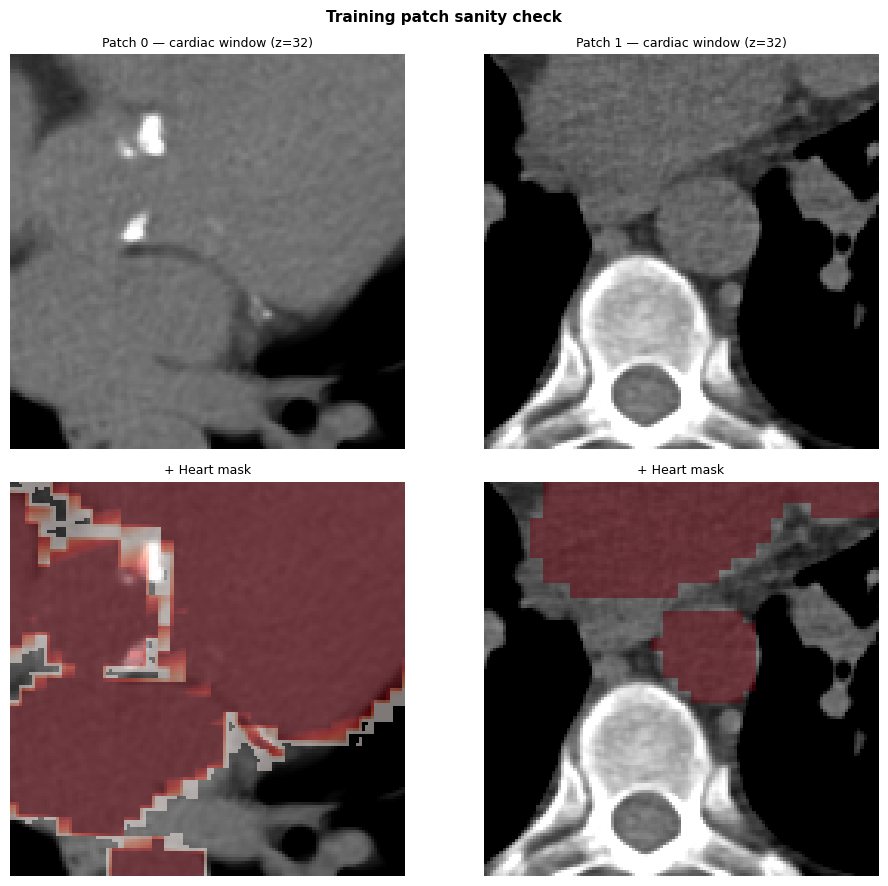

In [9]:
# Quick sanity check: one training patch batch from fold-0 data
_fold0_train = cv_scans[:int(len(cv_scans) * 0.8)]
_ds_check    = HeartPatch3DDataset(_fold0_train, augment=True,
                                   samples_per_volume=2, pos_prob=0.67)
_dl_check    = DataLoader(_ds_check, batch_size=2, shuffle=True, num_workers=0)
imgs, masks  = next(iter(_dl_check))
print(f"Patch batch  image : {tuple(imgs.shape)}  mask : {tuple(masks.shape)}")
print(f"Image range        : [{imgs.min():.3f}, {imgs.max():.3f}]")
print(f"Heart voxels       : {masks.sum().item():.0f} / {masks.numel()} "
      f"({masks.mean().item()*100:.2f} %)")
del _ds_check, _dl_check, _fold0_train

mid_z = PATCH_SIZE[0] // 2
fig, axes = plt.subplots(2, 2, figsize=(10, 9))
for i in range(2):
    axes[0, i].imshow(imgs[i, 1, mid_z].numpy(), cmap="gray")
    axes[0, i].set_title(f"Patch {i} — cardiac window (z={mid_z})", fontsize=9)
    axes[0, i].axis("off")
    axes[1, i].imshow(imgs[i, 1, mid_z].numpy(), cmap="gray")
    axes[1, i].imshow(masks[i, 0, mid_z].numpy(), cmap="Reds",
                      alpha=0.5 * (masks[i, 0, mid_z].numpy() > 0))
    axes[1, i].set_title("+ Heart mask", fontsize=9)
    axes[1, i].axis("off")
plt.suptitle("Training patch sanity check", fontsize=11, weight="bold")
plt.tight_layout()
plt.show()


## 3. MONAI 3-D U-Net

`spatial_dims=3` captures inter-slice cardiac anatomy.
Channels `(32, 64, 128, 256)` give the model ~4 M parameters —
enough representational power to learn complex 3-D cardiac boundaries
while remaining trainable in 5 folds on a Colab T4 GPU.


In [7]:
def build_model(device=DEVICE):
    # Doubled channels (16,32,64,128) → (32,64,128,256): ~4× more parameters,
    # significantly more representational power for 3-D cardiac anatomy.
    return MonaiUNet(
        spatial_dims  = 3,
        in_channels   = IN_CH,     # 2 multi-window channels (from Preprocessing config)
        out_channels  = 1,
        channels      = (32, 64, 128, 256),
        strides       = (2, 2, 2),
        num_res_units = 2,
        act           = "PRELU",
        norm          = "BATCH",
        dropout       = 0.1,
    ).to(device)

model    = build_model()
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"3-D MONAI U-Net  |  {n_params:,} params  ({n_params/1e6:.2f} M)")

with torch.no_grad():
    dummy = torch.zeros(1, IN_CH, *PATCH_SIZE, device=DEVICE)
    out   = model(dummy)
    print(f"Input  {tuple(dummy.shape)}  →  Output {tuple(out.shape)}")
print(model)


3-D MONAI U-Net  |  4,742,092 params  (4.74 M)
Input  (1, 2, 64, 128, 128)  →  Output (1, 1, 64, 128, 128)
UNet(
  (model): Sequential(
    (0): ResidualUnit(
      (conv): Sequential(
        (unit0): Convolution(
          (conv): Conv3d(2, 32, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
          (adn): ADN(
            (N): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (D): Dropout(p=0.1, inplace=False)
            (A): PReLU(num_parameters=1)
          )
        )
        (unit1): Convolution(
          (conv): Conv3d(32, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (adn): ADN(
            (N): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (D): Dropout(p=0.1, inplace=False)
            (A): PReLU(num_parameters=1)
          )
        )
      )
      (residual): Conv3d(2, 32, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
    )
    (1

## 4. Loss Functions & Epoch Utilities

`0.5 × DiceLoss + 0.5 × BCEWithLogitsLoss(pos_weight)` — Dice handles structural
class imbalance, BCE gives stable per-voxel gradients. Gradient clipping at 1.0
prevents exploding gradients on small patch batches.


In [8]:
dice_loss_fn = DiceLoss(sigmoid=True, smooth_nr=1e-5, smooth_dr=1e-5)
bce_loss_fn  = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(DEVICE))

def combined_loss(logits, targets):
    return 0.5 * dice_loss_fn(logits, targets) + 0.5 * bce_loss_fn(logits, targets)

def dice_score_batch(logits, targets, thr=0.5, eps=1e-6):
    preds = (torch.sigmoid(logits) > thr).float()
    inter = (preds * targets).sum(dim=(1, 2, 3, 4))
    union = preds.sum(dim=(1, 2, 3, 4)) + targets.sum(dim=(1, 2, 3, 4))
    return ((2 * inter + eps) / (union + eps)).mean().item()

def train_one_epoch(model, loader, optimizer, device):
    model.train()
    tot_loss, tot_dice, n = 0., 0., 0
    for imgs, masks in loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = combined_loss(logits, masks)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        tot_loss += loss.item()
        tot_dice += dice_score_batch(logits.detach(), masks)
        n += 1
    return tot_loss / n, tot_dice / n

@torch.no_grad()
def validate(model, loader, device):
    model.eval()
    tot_loss, tot_dice, n = 0., 0., 0
    for imgs, masks in loader:
        imgs, masks = imgs.to(device), masks.to(device)
        logits = model(imgs)
        tot_loss += combined_loss(logits, masks).item()
        tot_dice += dice_score_batch(logits, masks)
        n += 1
    return tot_loss / n, tot_dice / n

print(f"Loss fns ready.  pos_weight = {pos_weight.item():.1f}")


Loss fns ready.  pos_weight = 6.3


## 5. K-Fold Training

Each fold trains from scratch. The checkpoint with the best **validation Dice**
across all folds is saved as `heart_unet3d_best.pth` and used for final test evaluation.


 Note: I stopped training from fold3 due to limited gpu resources at colab


In [9]:
kf            = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
cv_scans_arr  = np.array(cv_scans)

fold_histories  = []
fold_best_dices = []
overall_best_dice = 0.0
best_ckpt_path = MODEL_DIR / "heart_unet3d_best.pth"

for fold, (train_idx, val_idx) in enumerate(kf.split(cv_scans_arr)):
    fold_train = cv_scans_arr[train_idx].tolist()
    fold_val   = cv_scans_arr[val_idx].tolist()

    print(f"\n{'='*70}")
    print(f"  FOLD {fold+1}/{N_FOLDS}  |  train={len(fold_train)}  val={len(fold_val)}")
    print(f"{'='*70}")

    # Datasets
    train_ds = HeartPatch3DDataset(fold_train, augment=True,
                                   samples_per_volume=8, pos_prob=0.67)
    val_ds   = HeartPatch3DDataset(fold_val,   augment=False,
                                   samples_per_volume=4, pos_prob=0.50)
    train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE_3D, shuffle=True,
                          num_workers=0, pin_memory=True)
    val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE_3D, shuffle=False,
                          num_workers=0, pin_memory=True)

    # Fresh model + optimizer every fold
    model     = build_model()
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=LR / 20)

    fold_history = {"train_loss": [], "train_dice": [], "val_loss": [], "val_dice": []}
    best_val_dice = 0.0
    patience_ctr  = 0
    fold_ckpt     = MODEL_DIR / f"heart_unet3d_fold{fold+1}.pth"

    for epoch in range(1, EPOCHS + 1):
        t0 = time.time()
        tr_loss, tr_dice = train_one_epoch(model, train_dl, optimizer, DEVICE)
        va_loss, va_dice = validate(model, val_dl, DEVICE)
        scheduler.step()

        fold_history["train_loss"].append(tr_loss)
        fold_history["train_dice"].append(tr_dice)
        fold_history["val_loss"].append(va_loss)
        fold_history["val_dice"].append(va_dice)

        mark = " *" if va_dice > best_val_dice else ""
        print(f"  Ep {epoch:02d}/{EPOCHS}  "
              f"tr={tr_dice:.4f}  va={va_dice:.4f}  "
              f"lr={scheduler.get_last_lr()[0]:.2e}  {time.time()-t0:.0f}s{mark}")

        if va_dice > best_val_dice:
            best_val_dice = va_dice
            torch.save({"fold": fold+1, "epoch": epoch,
                        "model_state": model.state_dict(),
                        "val_dice": va_dice,
                        "arch": {"spatial_dims": 3, "in_channels": IN_CH,
                                 "channels": (32,64,128,256),
                                 "strides": (2,2,2), "num_res_units": 2}},
                       fold_ckpt)
            patience_ctr = 0
            # Save as overall best if this fold topped everything so far
            if va_dice > overall_best_dice:
                overall_best_dice = va_dice
                import shutil
                shutil.copy(fold_ckpt, best_ckpt_path)
                print(f"    => New overall best: {overall_best_dice:.4f} (fold {fold+1})")
        else:
            patience_ctr += 1
            if patience_ctr >= PATIENCE:
                print(f"  Early stop at epoch {epoch}.")
                break

    fold_best_dices.append(best_val_dice)
    fold_histories.append(fold_history)
    print(f"  Fold {fold+1} best val Dice: {best_val_dice:.4f}")

''' # Summary across folds
print(f"\n{'='*70}")
print(f"  K-FOLD CV RESULTS ({N_FOLDS} folds)")
print(f"{'='*70}")
for i, d in enumerate(fold_best_dices):
    print(f"  Fold {i+1}: best val Dice = {d:.4f}")
print(f"\n  Mean val Dice : {np.mean(fold_best_dices):.4f} +/- {np.std(fold_best_dices):.4f}")
print(f"  Best overall  : {overall_best_dice:.4f}  -> {best_ckpt_path}")

# Learning curves — all folds overlaid
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = plt.cm.tab10.colors
for i, h in enumerate(fold_histories):
    ep = range(1, len(h["val_loss"]) + 1)
    ax1.plot(ep, h["val_loss"],  color=colors[i], label=f"Fold {i+1}")
    ax2.plot(ep, h["val_dice"],  color=colors[i], label=f"Fold {i+1}")
ax2.axhline(DICE_TARGET, color="green", linestyle="--", label=f"Target {DICE_TARGET}")
ax1.set_title("Val Loss per Fold");  ax1.set_xlabel("Epoch"); ax1.legend(fontsize=8)
ax2.set_title("Val Dice per Fold");  ax2.set_xlabel("Epoch"); ax2.legend(fontsize=8)
plt.suptitle(f"K-Fold CV ({N_FOLDS} folds) — 3-D MONAI U-Net", fontsize=13, weight="bold")
plt.tight_layout()
plt.savefig(config.OUTPUT_DIR / "seg_kfold_curves.png", dpi=150, bbox_inches="tight")
plt.show() '''



  FOLD 1/5  |  train=33  val=9
Initialized CardiacCTDataset with 33 scans (augment=False, cache=True)
  33 vols × 8 = 264 patches  augment=True
Initialized CardiacCTDataset with 9 scans (augment=False, cache=True)
  9 vols × 4 = 36 patches  augment=False
  Ep 01/30  tr=0.5745  va=0.6575  lr=2.99e-04  163s *
    => New overall best: 0.6575 (fold 1)
  Ep 02/30  tr=0.6688  va=0.7197  lr=2.97e-04  158s *
    => New overall best: 0.7197 (fold 1)
  Ep 03/30  tr=0.7694  va=0.7956  lr=2.93e-04  152s *
    => New overall best: 0.7956 (fold 1)
  Ep 04/30  tr=0.7935  va=0.3981  lr=2.88e-04  147s
  Ep 05/30  tr=0.8196  va=0.8476  lr=2.81e-04  159s *
    => New overall best: 0.8476 (fold 1)
  Ep 06/30  tr=0.8296  va=0.8209  lr=2.73e-04  150s
  Ep 07/30  tr=0.8443  va=0.8497  lr=2.63e-04  151s *
    => New overall best: 0.8497 (fold 1)
  Ep 08/30  tr=0.8370  va=0.8182  lr=2.53e-04  158s
  Ep 09/30  tr=0.8655  va=0.8620  lr=2.41e-04  145s *
    => New overall best: 0.8620 (fold 1)
  Ep 10/30  tr=0.8

KeyboardInterrupt: 


  K-FOLD CV RESULTS (Completed 2 folds)
  Fold 1: best val Dice = 0.9295
  Fold 2: best val Dice = 0.9300

  Mean val Dice : 0.9297 +/- 0.0003
  Best overall  : 0.9300  -> Fold 2


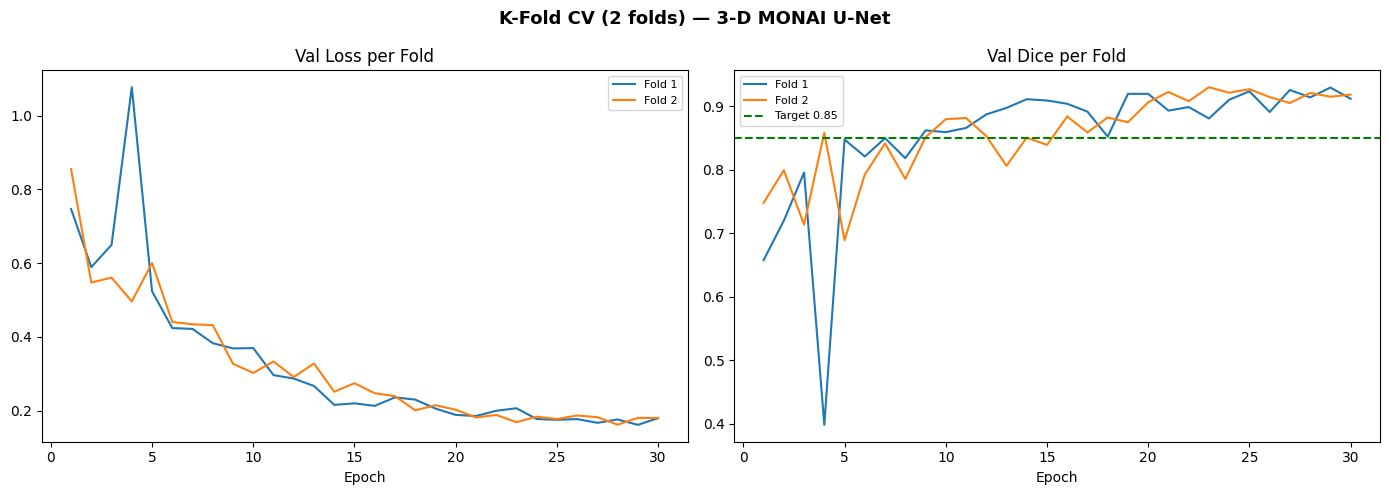

In [10]:

completed_folds = [(i, h, d) for i, (h, d) in enumerate(zip(fold_histories, fold_best_dices)) if h is not None and len(h) > 0]

# Summary across completed folds
print(f"\n{'='*70}")
print(f"  K-FOLD CV RESULTS (Completed {len(completed_folds)} folds)")
print(f"{'='*70}")
for i, h, d in completed_folds:
    print(f"  Fold {i+1}: best val Dice = {d:.4f}")
if completed_folds:
    dices = [d for _, _, d in completed_folds]
    print(f"\n  Mean val Dice : {np.mean(dices):.4f} +/- {np.std(dices):.4f}")
    best_idx = np.argmax(dices)
    print(f"  Best overall  : {dices[best_idx]:.4f}  -> Fold {completed_folds[best_idx][0]+1}")
# ploting completed folds
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = plt.cm.tab10.colors

for i, h, _ in completed_folds:
    ep = range(1, len(h["val_loss"]) + 1)
    ax1.plot(ep, h["val_loss"],  color=colors[i], label=f"Fold {i+1}")
    ax2.plot(ep, h["val_dice"],  color=colors[i], label=f"Fold {i+1}")


if 'DICE_TARGET' in globals():
    ax2.axhline(DICE_TARGET, color="green", linestyle="--", label=f"Target {DICE_TARGET}")

ax1.set_title("Val Loss per Fold")
ax1.set_xlabel("Epoch")
ax1.legend(fontsize=8)

ax2.set_title("Val Dice per Fold")
ax2.set_xlabel("Epoch")
ax2.legend(fontsize=8)

plt.suptitle(f"K-Fold CV ({len(completed_folds)} folds) — 3-D MONAI U-Net", fontsize=13, weight="bold")
plt.tight_layout()

# Save only if output dir exists
from pathlib import Path
out_dir = Path(config.OUTPUT_DIR)
out_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(out_dir / "seg_kfold_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Evaluation: Full-Volume Dice vs TotalSegmentator + Inference Time

The best checkpoint (highest val Dice across all folds) is evaluated on the fixed
held-out test set using `SlidingWindowInferer` with Gaussian blending.

U-Net inference is timed on both GPU and CPU so the comparison against
TotalSegmentator (which was run on CPU) is hardware-fair.


In [18]:
# ── Reload best K-Fold checkpoint and evaluate ───────────────────────────────
from pathlib import Path
import time
import torch
import numpy as np
from monai.inferers import SlidingWindowInferer

best_ckpt_path = MODEL_DIR / "heart_unet3d_best.pth"

# ------------------- Load best K-Fold model -------------------
model = build_model()
ckpt = torch.load(best_ckpt_path, map_location=DEVICE, weights_only=True)
model.load_state_dict(ckpt["model_state"])
model.eval()
fold_str = ckpt.get("fold", "?")
epoch_str = ckpt.get("epoch", "?")
val_dice_str = ckpt.get("val_dice", 0.0)
print(f"Best checkpoint: fold={fold_str}  epoch={epoch_str}  val_dice={val_dice_str:.4f}")

# ------------------- Prepare CPU model -------------------
CPU_DEVICE = torch.device("cpu")
model_cpu = build_model(device=CPU_DEVICE)
model_cpu.load_state_dict(ckpt["model_state"])
model_cpu.eval()

# ------------------- Sliding Window Inferers -------------------
inferer_gpu = SlidingWindowInferer(roi_size=PATCH_SIZE, sw_batch_size=2, overlap=SW_OVERLAP, mode="gaussian")
inferer_cpu = SlidingWindowInferer(roi_size=PATCH_SIZE, sw_batch_size=1, overlap=SW_OVERLAP, mode="gaussian")

# ------------------- Evaluation function -------------------
@torch.no_grad()
def evaluate_scan(sample, mdl, inferer, device):
    img = sample["image"].unsqueeze(0)
    gt = sample["mask"].numpy()[0]
    t0 = time.perf_counter()
    prob_map = torch.sigmoid(inferer(img.to(device), mdl)).squeeze().cpu().numpy()
    t_inf = time.perf_counter() - t0
    pred = (prob_map > 0.5).astype(np.float32)
    inter = (pred * gt).sum()
    union = pred.sum() + gt.sum()
    dice = float((2 * inter + 1e-6) / (union + 1e-6))
    return dice, t_inf, pred

# ------------------- Load full-volume test dataset -------------------
test_vol_ds = CardiacCTDataset(test_scans, config.DATA_DIR, config, augment=False, cache=True)

# ------------------- CPU warm-up -------------------
print("Warming up CPU inferer…", end=" ", flush=True)
evaluate_scan(test_vol_ds[0], model_cpu, inferer_cpu, CPU_DEVICE)
print("done.\nEvaluating...\n")

# ------------------- Evaluate all scans -------------------
print(f"{'':1}{'Scan':>14}  {'Dice':>6}  {'GPU(s)':>7}  {'CPU(s)':>7}  {'TS(s)':>7}  {'Spd-GPU':>8}  {'Spd-CPU':>8}")
print("-" * 80)

results = []
for sample in test_vol_ds:
    sid = sample["scan_id"]
    dice, t_gpu, pred = evaluate_scan(sample, model, inferer_gpu, DEVICE)
    _, t_cpu, _ = evaluate_scan(sample, model_cpu, inferer_cpu, CPU_DEVICE)

    ts_t = ts_times.get(sid, float("nan"))
    spd_gpu = f"{ts_t/t_gpu:.0f}x" if not np.isnan(ts_t) else "n/a"
    spd_cpu = f"{ts_t/t_cpu:.0f}x" if not np.isnan(ts_t) else "n/a"
    ok = "+" if dice >= DICE_TARGET else "-"

    print(f"{ok} {sid[:12]:>12}  {dice:>6.4f}  {t_gpu:>7.1f}  {t_cpu:>7.1f}  {ts_t:>7.0f}  {spd_gpu:>8}  {spd_cpu:>8}")

    results.append({
        "scan_id": sid,
        "dice": dice,
        "unet_gpu_sec": t_gpu,
        "unet_cpu_sec": t_cpu,
        "ts_time_sec": ts_t,
        "n_slices": sample["mask"].shape[0],
        "pred_vol": pred,
        "seg_gt": sample["mask"].numpy()[0],
        "img_vol": sample["image"][1].numpy()
    })

# ------------------- Aggregate results -------------------
dice_vals = [r["dice"] for r in results]
gpu_times = [r["unet_gpu_sec"] for r in results]
cpu_times = [r["unet_cpu_sec"] for r in results]

ts_t_vals = [r["ts_time_sec"] for r in results if not np.isnan(r["ts_time_sec"])]
spd_gpu_v = [r["ts_time_sec"]/r["unet_gpu_sec"] for r in results if not np.isnan(r["ts_time_sec"])]
spd_cpu_v = [r["ts_time_sec"]/r["unet_cpu_sec"] for r in results if not np.isnan(r["ts_time_sec"])]

print("\n" + "=" * 80)
print(f"  K-Fold CV mean val Dice : {np.mean(fold_best_dices):.4f} +/- {np.std(fold_best_dices):.4f}")
print(f"  Test mean Dice          : {np.mean(dice_vals):.4f} +/- {np.std(dice_vals):.4f}")
print(f"  Test scans >= {DICE_TARGET}       : {sum(d >= DICE_TARGET for d in dice_vals)}/{len(results)}")

if ts_t_vals:
    print(f"  Speedup GPU vs TS CPU   : median {np.median(spd_gpu_v):.0f}x")
    print(f"  Speedup CPU vs TS CPU   : median {np.median(spd_cpu_v):.0f}x  (fair comparison)")
print("=" * 80)

Best checkpoint: fold=2  epoch=23  val_dice=0.9300
Initialized CardiacCTDataset with 8 scans (augment=False, cache=True)
Warming up CPU inferer… 

Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)


done.
Evaluating...

           Scan    Dice   GPU(s)   CPU(s)    TS(s)   Spd-GPU   Spd-CPU
--------------------------------------------------------------------------------


Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)


- 455b6c2c2b12  0.8314      0.5     16.1      220      470x       14x
+ 9756fc8b9abc  0.9049      0.4     16.2      191      443x       12x
+ a230e5ddcf05  0.9344      0.4     16.1      221      515x       14x
- d3e0b8da9504  0.5228      0.9     37.5      414      452x       11x
- 503ebfb68f2f  0.8247      0.7     26.1      230      341x        9x
+ e250f130b0c7  0.9071      0.3      9.6      156      587x       16x
+ 719067c79875  0.9296      0.5     16.4      370      798x       23x
+ 242eaebd37d9  0.8923      0.7     28.3      302      458x       11x

  K-Fold CV mean val Dice : 0.9297 +/- 0.0003
  Test mean Dice          : 0.8434 +/- 0.1271
  Test scans >= 0.85       : 5/8
  Speedup GPU vs TS CPU   : median 464x
  Speedup CPU vs TS CPU   : median 13x  (fair comparison)


## Results with LLC post-processing
>the results is slightly better when removing tiny false postive



In [12]:
# ── Reload best K-Fold checkpoint and evaluate  ───────────────────────────────
from pathlib import Path
import time
import torch
from scipy import ndimage
from monai.inferers import SlidingWindowInferer

best_ckpt_path = MODEL_DIR / "heart_unet3d_best.pth"

# ------------------- Load best K-Fold model -------------------
model = build_model()
ckpt  = torch.load(best_ckpt_path, map_location=DEVICE, weights_only=True)
model.load_state_dict(ckpt["model_state"])
model.eval()

fold_str     = ckpt.get("fold", "?")
epoch_str    = ckpt.get("epoch", "?")
val_dice_str = ckpt.get("val_dice", 0.0)
print(f"Best checkpoint: fold={fold_str}  epoch={epoch_str}  val_dice={val_dice_str:.4f}")

# ------------------- Prepare CPU model -------------------
CPU_DEVICE = torch.device("cpu")
model_cpu  = build_model(device=CPU_DEVICE)
model_cpu.load_state_dict(ckpt["model_state"])
model_cpu.eval()

# ------------------- Sliding Window Inferers -------------------
inferer_gpu = SlidingWindowInferer(roi_size=PATCH_SIZE, sw_batch_size=2, overlap=SW_OVERLAP, mode="gaussian")
inferer_cpu = SlidingWindowInferer(roi_size=PATCH_SIZE, sw_batch_size=1, overlap=SW_OVERLAP, mode="gaussian")

# ------------------- Largest Connected Component (LCC) post-processing -------------------
def keep_largest_component(binary_vol: np.ndarray) -> np.ndarray:
    """Zero out all but the largest foreground connected component."""
    if binary_vol.sum() == 0:
        return binary_vol
    labeled, n_comps = ndimage.label(binary_vol)
    if n_comps <= 1:
        return binary_vol
    sizes  = ndimage.sum(binary_vol, labeled, range(1, n_comps + 1))
    best   = int(np.argmax(sizes)) + 1
    return (labeled == best).astype(np.float32)

# ------------------- Evaluation function  -------------------
@torch.no_grad()
def evaluate_scan(sample, mdl, inferer, device, lcc=True):
    """Evaluate a single scan using sliding window inference."""
    img = sample["image"].unsqueeze(0)
    gt  = sample["mask"].numpy()[0]
    t0  = time.perf_counter()
    prob_map = torch.sigmoid(inferer(img.to(device), mdl)).squeeze().cpu().numpy()
    t_inf = time.perf_counter() - t0
    pred  = (prob_map > 0.5).astype(np.float32)
    if lcc:
        pred = keep_largest_component(pred)
    inter = (pred * gt).sum()
    union = pred.sum() + gt.sum()
    dice  = float((2 * inter + 1e-6) / (union + 1e-6))
    return dice, t_inf, pred

# ------------------- Load full-volume test dataset -------------------
test_vol_ds = CardiacCTDataset(test_scans, config.DATA_DIR, config, augment=False, cache=True)

# CPU warm-up
print("Warming up CPU inferer…", end=" ", flush=True)
evaluate_scan(test_vol_ds[0], model_cpu, inferer_cpu, CPU_DEVICE, lcc=False)
print("done.\n")
print("Evaluating with LCC post-processing…\n")

# ------------------- Evaluate all scans -------------------
print(f"{'':1}{'Scan':>14}  {'Dice':>6}  {'GPU(s)':>7}  {'CPU(s)':>7}  "
      f"{'TS(s)':>7}  {'Spd-GPU':>8}  {'Spd-CPU':>8}")
print("-" * 80)

results = []
for sample in test_vol_ds:
    sid = sample["scan_id"]
    dice,  t_gpu, pred = evaluate_scan(sample, model, inferer_gpu, DEVICE, lcc=True)
    _,     t_cpu, _    = evaluate_scan(sample, model_cpu, inferer_cpu, CPU_DEVICE, lcc=True)
    ts_t   = ts_times.get(sid, float("nan"))
    spd_gpu = f"{ts_t/t_gpu:.0f}x" if not np.isnan(ts_t) else "n/a"
    spd_cpu = f"{ts_t/t_cpu:.0f}x" if not np.isnan(ts_t) else "n/a"
    ok = "+" if dice >= DICE_TARGET else "-"
    print(f"{ok} {sid[:12]:>12}  {dice:>6.4f}  {t_gpu:>7.1f}  {t_cpu:>7.1f}  "
          f"{ts_t:>7.0f}  {spd_gpu:>8}  {spd_cpu:>8}")
    results.append({
        "scan_id": sid, "dice": dice,
        "unet_gpu_sec": t_gpu, "unet_cpu_sec": t_cpu,
        "ts_time_sec": ts_t, "n_slices": sample["mask"].shape[0],
        "pred_vol": pred, "seg_gt": sample["mask"].numpy()[0],
        "img_vol": sample["image"][1].numpy()
    })

# ------------------- Aggregate results -------------------
dice_vals = [r["dice"] for r in results]
gpu_times = [r["unet_gpu_sec"] for r in results]
cpu_times = [r["unet_cpu_sec"] for r in results]
ts_t_vals = [r["ts_time_sec"] for r in results if not np.isnan(r["ts_time_sec"])]
spd_gpu_v = [r["ts_time_sec"]/r["unet_gpu_sec"] for r in results if not np.isnan(r["ts_time_sec"])]
spd_cpu_v = [r["ts_time_sec"]/r["unet_cpu_sec"] for r in results if not np.isnan(r["ts_time_sec"])]

print("\n" + "=" * 80)
print(f"  K-Fold CV mean val Dice : {np.mean(fold_best_dices):.4f} +/- {np.std(fold_best_dices):.4f}")
print(f"  Test mean Dice          : {np.mean(dice_vals):.4f} +/- {np.std(dice_vals):.4f}")
print(f"  Test scans >= {DICE_TARGET}       : {sum(d >= DICE_TARGET for d in dice_vals)}/{len(results)}")
if ts_t_vals:
    print(f"  Speedup GPU vs TS CPU   : median {np.median(spd_gpu_v):.0f}x")
    print(f"  Speedup CPU vs TS CPU   : median {np.median(spd_cpu_v):.0f}x  (fair comparison)")
print("=" * 80)

Best checkpoint: fold=2  epoch=23  val_dice=0.9300
Initialized CardiacCTDataset with 8 scans (augment=False, cache=True)
Warming up CPU inferer… done.

Evaluating with LCC post-processing…

           Scan    Dice   GPU(s)   CPU(s)    TS(s)   Spd-GPU   Spd-CPU
--------------------------------------------------------------------------------
+ 455b6c2c2b12  0.8668      0.4     16.1      220      507x       14x
+ 9756fc8b9abc  0.9233      0.4     16.1      191      440x       12x
+ a230e5ddcf05  0.9342      0.4     16.3      221      513x       14x
- d3e0b8da9504  0.5932      0.9     36.6      414      453x       11x
- 503ebfb68f2f  0.7861      0.7     25.5      230      350x        9x
+ e250f130b0c7  0.9171      0.3      9.6      156      561x       16x
+ 719067c79875  0.9020      0.5     16.0      370      797x       23x
+ 242eaebd37d9  0.9168      0.7     25.8      302      440x       12x

  K-Fold CV mean val Dice : 0.9297 +/- 0.0003
  Test mean Dice          : 0.8549 +/- 0.1085
  Tes

## 7. Visualizations


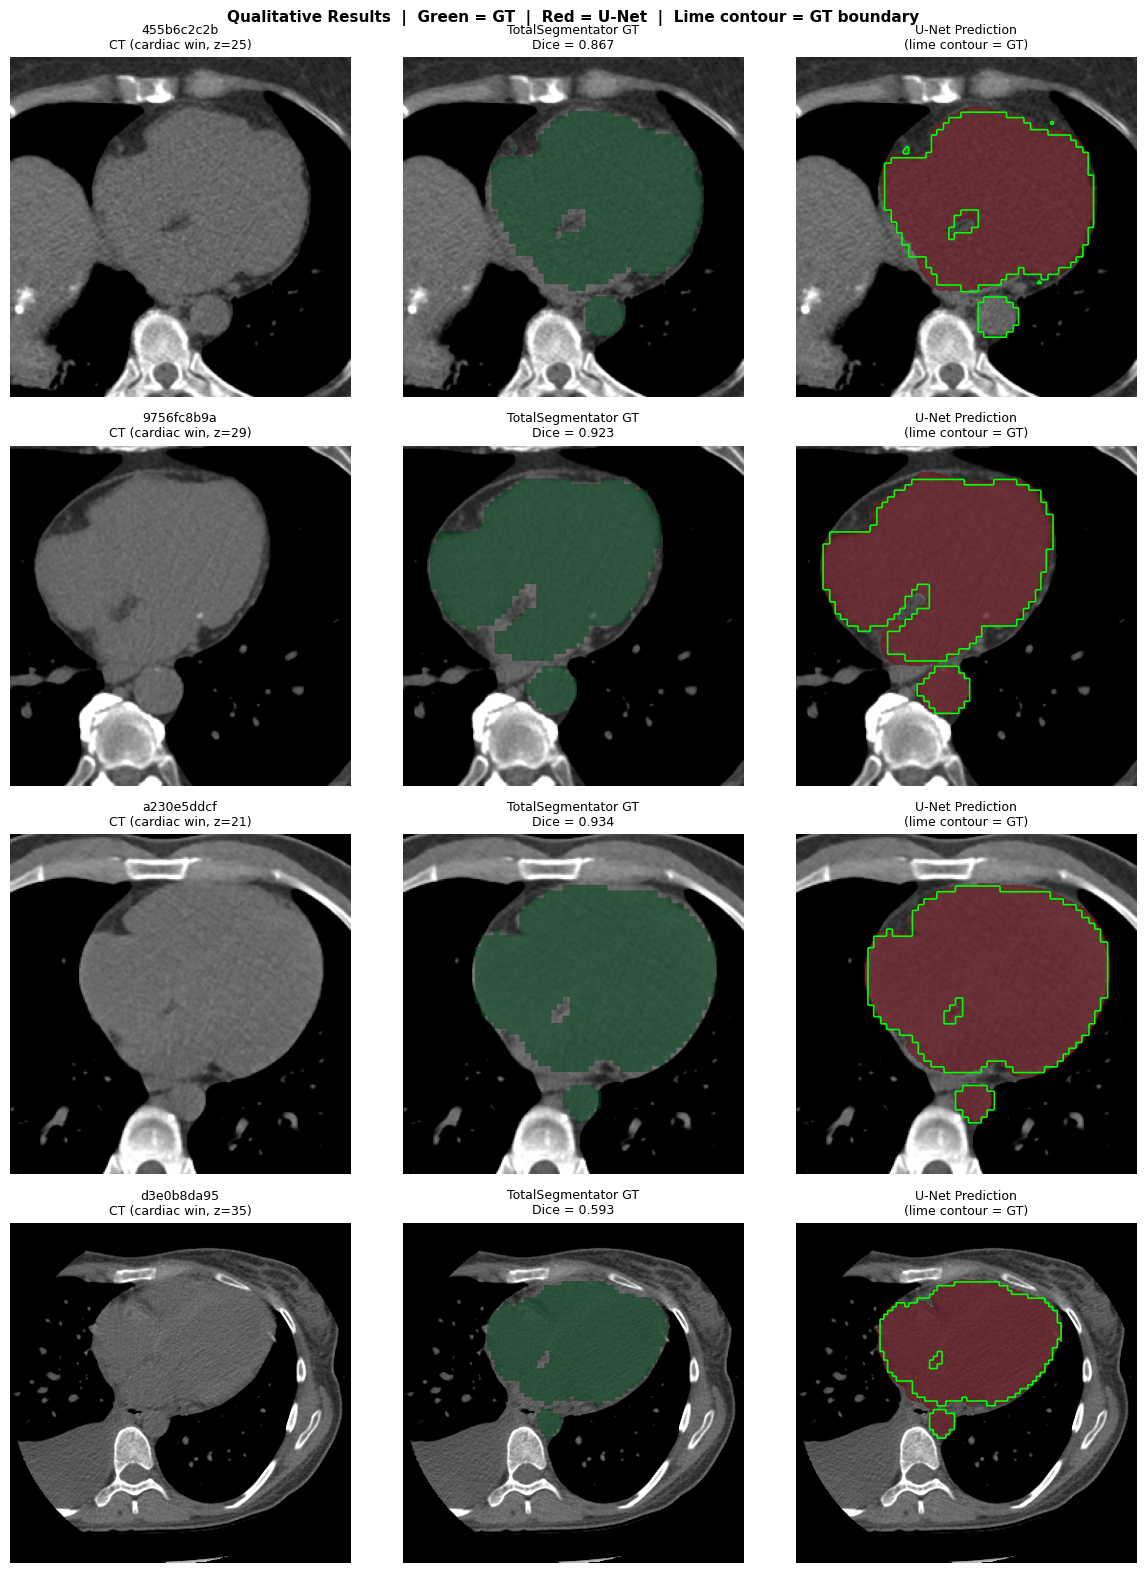

In [17]:
# Qualitative: CT | GT | Prediction for up to 4 test scans
import pandas as pd

n_show = min(4, len(results))
fig, axes = plt.subplots(n_show, 3, figsize=(12, 4 * n_show))
if n_show == 1:
    axes = axes[np.newaxis, :]

for row, r in enumerate(results[:n_show]):
    ct   = r["img_vol"]    # (D, H, W) cardiac window [0,1] — from Preprocessing
    gt   = r["seg_gt"]     # binary
    pred = r["pred_vol"]   # binary

    z = int(np.argmax(gt.sum(axis=(1, 2)))) if gt.sum() > 0 else ct.shape[0] // 2

    axes[row, 0].imshow(ct[z], cmap="gray")
    axes[row, 0].set_title(f"{r['scan_id'][:10]}\nCT (cardiac win, z={z})", fontsize=9)
    axes[row, 0].axis("off")

    axes[row, 1].imshow(ct[z], cmap="gray")
    axes[row, 1].imshow(np.ma.masked_where(gt[z] == 0, gt[z]),
                        cmap="Greens", alpha=0.55, vmin=0, vmax=1)
    axes[row, 1].set_title(f"TotalSegmentator GT\nDice = {r['dice']:.3f}", fontsize=9)
    axes[row, 1].axis("off")

    axes[row, 2].imshow(ct[z], cmap="gray")
    axes[row, 2].imshow(np.ma.masked_where(pred[z] == 0, pred[z]),
                        cmap="Reds", alpha=0.55, vmin=0, vmax=1)
    try:
        axes[row, 2].contour(gt[z], levels=[0.5], colors=["lime"], linewidths=[1.2])
    except Exception:
        pass
    axes[row, 2].set_title("U-Net Prediction\n(lime contour = GT)", fontsize=9)
    axes[row, 2].axis("off")

plt.suptitle("Qualitative Results  |  Green = GT  |  Red = U-Net  |  Lime contour = GT boundary",
             fontsize=11, weight="bold")
plt.tight_layout()
plt.savefig(config.OUTPUT_DIR / "seg_qualitative.png", dpi=150, bbox_inches="tight")
plt.show()

In [15]:
results_df = pd.DataFrame([{
    "scan_id"       : r["scan_id"],
    "dice"          : round(r["dice"],           4),
    "unet_gpu_sec"  : round(r["unet_gpu_sec"],   2),
    "unet_cpu_sec"  : round(r["unet_cpu_sec"],   2),
    "totalseg_sec"  : round(r["ts_time_sec"],    1),
    "speedup_gpu_x" : round(r["ts_time_sec"] / r["unet_gpu_sec"], 1)
                       if not np.isnan(r["ts_time_sec"]) else float("nan"),
    "speedup_cpu_x" : round(r["ts_time_sec"] / r["unet_cpu_sec"], 1)
                       if not np.isnan(r["ts_time_sec"]) else float("nan"),
    "n_slices"      : r["n_slices"],
    "meets_target"  : r["dice"] >= DICE_TARGET,
} for r in results])

summary = pd.DataFrame([{
    "scan_id"       : "MEAN",
    "dice"          : round(results_df["dice"].mean(),         4),
    "unet_gpu_sec"  : round(results_df["unet_gpu_sec"].mean(), 2),
    "unet_cpu_sec"  : round(results_df["unet_cpu_sec"].mean(), 2),
    "totalseg_sec"  : round(results_df["totalseg_sec"].mean(), 1),
    "speedup_gpu_x" : round(results_df["speedup_gpu_x"].mean(), 1),
    "speedup_cpu_x" : round(results_df["speedup_cpu_x"].mean(), 1),
    "n_slices"      : int(results_df["n_slices"].mean()),
    "meets_target"  : results_df["meets_target"].all(),
}])

kfold_summary = pd.DataFrame([{
    "scan_id": f"FOLD_{i+1}_VAL", "dice": round(d, 4),
    "unet_gpu_sec": float("nan"), "unet_cpu_sec": float("nan"),
    "totalseg_sec": float("nan"), "speedup_gpu_x": float("nan"),
    "speedup_cpu_x": float("nan"), "n_slices": 0, "meets_target": d >= DICE_TARGET,
} for i, d in enumerate(fold_best_dices)])

full_df = pd.concat([results_df, summary, kfold_summary], ignore_index=True)
print(full_df.to_string(index=False))

csv_path = config.OUTPUT_DIR / "seg_test_results.csv"
results_df.to_csv(csv_path, index=False)
print(f"\nSaved -> {csv_path}")
print(f"\nK-Fold CV val Dice: {np.mean(fold_best_dices):.4f} +/- {np.std(fold_best_dices):.4f}")
print("speedup_cpu_x is the hardware-fair metric (both on CPU).")


     scan_id   dice  unet_gpu_sec  unet_cpu_sec  totalseg_sec  speedup_gpu_x  speedup_cpu_x  n_slices  meets_target
455b6c2c2b12 0.8668          0.43         16.13         220.2          507.1           13.7         1          True
9756fc8b9abc 0.9233          0.43         16.09         191.5          440.2           11.9         1          True
a230e5ddcf05 0.9342          0.43         16.34         220.7          512.9           13.5         1          True
d3e0b8da9504 0.5932          0.91         36.60         414.3          452.8           11.3         1         False
503ebfb68f2f 0.7861          0.66         25.49         229.9          350.3            9.0         1         False
e250f130b0c7 0.9171          0.28          9.63         155.8          560.8           16.2         1          True
719067c79875 0.9020          0.46         16.03         370.5          797.1           23.1         1          True
242eaebd37d9 0.9168          0.69         25.82         302.5          4

## 8. Design Notes

### Why U-Net?
U-Net was chosen as the segmentation backbone for several well-founded reasons. Its **encoder–decoder architecture with skip connections** directly combats the information bottleneck that plagues plain encoder networks: high-resolution spatial detail from early layers is concatenated with upsampled feature maps, letting the decoder reconstruct precise object boundaries — critical for delineating the heart wall from neighbouring mediastinal structures at voxel level. The **3-D formulation** (`spatial_dims=3`) is essential here because cardiac anatomy is inherently volumetric; axial, coronal, and sagittal context all contribute to accurate segmentation, and a 3-D convolution sees all three simultaneously rather than treating slices independently. U-Net's inductive bias toward **local structure** maps naturally onto the heart, which occupies a compact, roughly convex region of the thorax. Finally, U-Net scales gracefully to small datasets: its fully convolutional design has no fully-connected layers, so the parameter count stays manageable (≈4 M with channels `(32, 64, 128, 256)`), and the architecture responds well to strong augmentation and patch-based training — both of which are critical when only 42 scans are available for cross-validation.

### Why K-Fold instead of a single split?
With only 50 scans, a single 70/15/15 split leaves 7–8 scans for validation —
giving a high-variance Dice estimate (±0.05 or more). 5-fold CV uses **all 42
non-test scans for training** across folds and reports mean ± std, making model
comparisons far more reliable. The fixed 8-scan test set is evaluated only once.

### Hardware-fair timing
TotalSegmentator was run on CPU. `speedup_cpu_x` (U-Net CPU vs TotalSeg CPU) is
the primary metric; `speedup_gpu_x` shows the deployment ceiling with a GPU.

### Deliverables (saved to Drive)
| Artefact | Path |
|---|---|
| Best model weights | `preprocessed_data/models/heart_unet3d_best.pth` |
| Per-fold checkpoints | `preprocessed_data/models/heart_unet3d_fold{N}.pth` |
| K-Fold learning curves | `preprocessed_data/seg_kfold_curves.png` |
| Evaluation summary plot | `preprocessed_data/seg_evaluation_summary.png` |
| Qualitative overlays | `preprocessed_data/seg_qualitative.png` |
| Per-scan results CSV | `preprocessed_data/seg_test_results.csv` |
